In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [2]:
adfs = {}
ldfs = {}
for file in Path("../runs/gamma-8/lattices/").iterdir():
    time = int(file.name.replace(".parquet", ""))
    ldfs[time] = pl.read_parquet(file)
    adfs[time] = pl.read_parquet(str(file).replace("lattices", "act_lattices"))

In [3]:
_neighs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]


def inbounds(x, y, w, h):
    if x < 0:
        return False
    if x > w - 1:
        return False
    if y < 0:
        return False
    if y > h - 1:
        return False
    return True


def neighs(x, y, w, h):
    return filter(lambda pos: inbounds(pos[0], pos[1], w, h), map(lambda pos: (pos[0] + x, pos[1] + y), _neighs))


# This is not quite what ava did.
# Try:
#   Using the geom mean of each pos
#   Taking the average per neighbour of the entire cell (use two NCELLS X NCELLS matrices to calculate the averages)
def act_sum_local(latdf: pl.DataFrame, actdf: pl.DataFrame):
    labels = []
    actvs = []
    for i in range(0, latdf.shape[0]):
        for j in range(0, latdf.shape[1]):
            for n in neighs(i, j, latdf.width, latdf.height):
                ij_sigma = latdf[i, j]
                if not ij_sigma.isnumeric():
                    continue
                n_sigma = latdf[*n]
                if ij_sigma == n_sigma:
                    continue
                act = actdf[i, j]
                if n_sigma.isnumeric():
                    lab = "c"
                else:
                    lab = n_sigma
                actvs.append(act)
                labels.append(lab)
                
    return pl.DataFrame({
        "label": labels,
        "act": actvs
    })


def act_sum_interface(latdf: pl.DataFrame, actdf: pl.DataFrame):
    cell1 = []
    cell2 = []
    actvs = []
    for i in range(0, latdf.shape[0]):
        for j in range(0, latdf.shape[1]):
            for n in neighs(i, j, latdf.width, latdf.height):
                ij_sigma = latdf[i, j]
                if not ij_sigma.isnumeric():
                    continue
                n_sigma = latdf[*n]
                if ij_sigma == n_sigma:
                    continue
                act = actdf[i, j]
                cell1.append(ij_sigma)
                cell2.append(n_sigma)
                actvs.append(act)
    df = pl.DataFrame({
        "cell1": cell1,
        "cell2": cell2,
        "act": actvs
    })
    df = df.group_by(["cell1", "cell2"]).agg(pl.col("act").mean())
    
    return df.with_columns(label=pl.Series("c" if x.isnumeric() and y.isnumeric() else y for x, y in zip(df["cell1"], df["cell2"]))).select(["label", "act"])


def act_sum_geom(latdf: pl.DataFrame, actdf: pl.DataFrame):
    labels = []
    actvs = []
    for i in range(0, latdf.shape[0]):
        for j in range(0, latdf.shape[1]):
            for n in neighs(i, j, latdf.width, latdf.height):
                ij_sigma = latdf[i, j]
                if not ij_sigma.isnumeric():
                    continue
                n_sigma = latdf[*n]
                if ij_sigma == n_sigma:
                    continue
                act = abs(geom_mean((i, j), latdf, actdf) - geom_mean(n, latdf, actdf))
                if n_sigma.isnumeric():
                    lab = "c"
                else:
                    lab = n_sigma
                actvs.append(act)
                labels.append(lab)
                
    return pl.DataFrame({
        "label": labels,
        "act": actvs
    })
    

def geom_mean(pos, latdf, actdf):
    pos_spin = latdf[*pos]
    act_prod = actdf[*pos]
    act_count = 1
    for neigh in neighs(pos[0], pos[1], latdf.width, latdf.height):
        if latdf[*neigh] != pos_spin:
            continue
        act_prod *= actdf[*neigh]
        act_count += 1
    return act_prod ** (1 / act_count)

In [5]:
asdf = act_sum_local(ldfs[5000000], adfs[5000000])

shape: (3, 3)
┌───────┬──────────┬───────┐
│ label ┆ mean_act ┆ count │
│ ---   ┆ ---      ┆ ---   │
│ str   ┆ f64      ┆ u32   │
╞═══════╪══════════╪═══════╡
│ m     ┆ 5.749565 ┆ 9767  │
│ s     ┆ 15.0     ┆ 3     │
│ c     ┆ 4.079245 ┆ 8480  │
└───────┴──────────┴───────┘


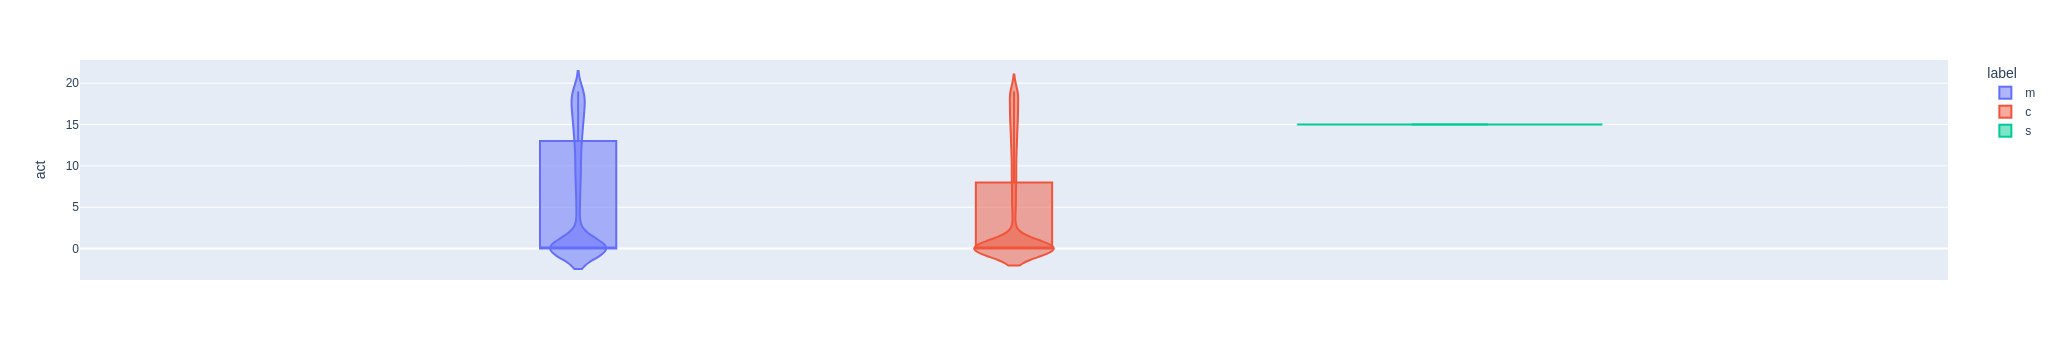

In [6]:
print(asdf.group_by("label").agg([pl.col("act").mean().alias("mean_act"), pl.col("act").count().alias("count")]))
px.violin(asdf, y="act", color="label", box=True)

In [8]:
asgdf = act_sum_geom(ldfs[5000000], adfs[5000000])

shape: (3, 3)
┌───────┬──────────┬───────┐
│ label ┆ mean_act ┆ count │
│ ---   ┆ ---      ┆ ---   │
│ str   ┆ f64      ┆ u32   │
╞═══════╪══════════╪═══════╡
│ m     ┆ 1.465834 ┆ 9767  │
│ c     ┆ 1.024522 ┆ 8480  │
│ s     ┆ 0.0      ┆ 3     │
└───────┴──────────┴───────┘


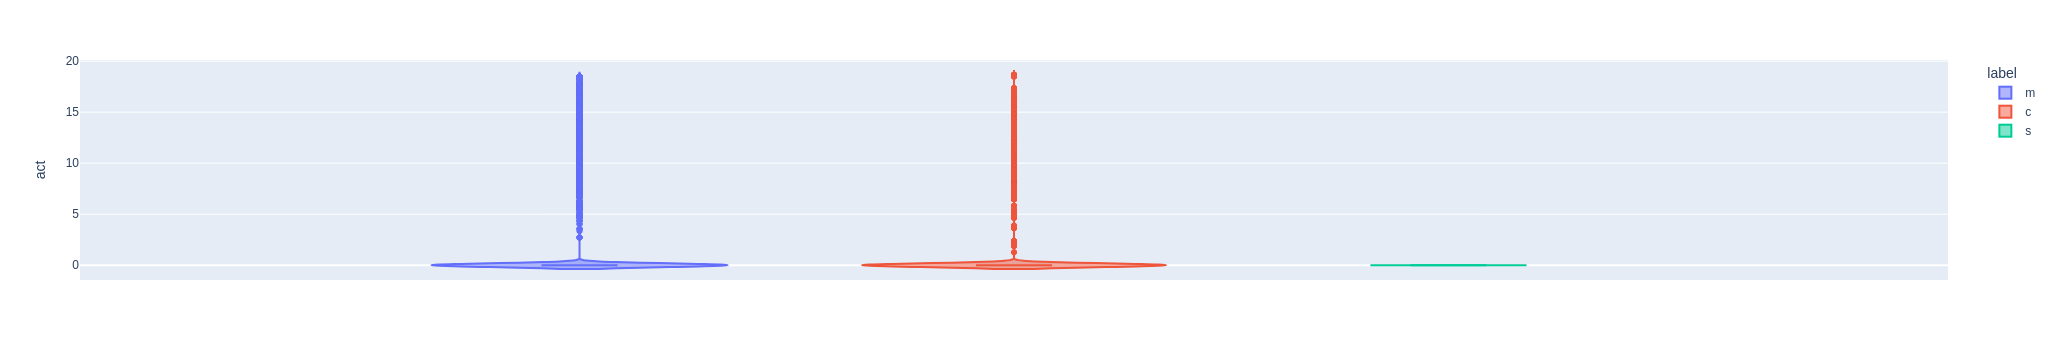

In [9]:
print(asgdf.group_by("label").agg([pl.col("act").mean().alias("mean_act"), pl.col("act").count().alias("count")]))
px.violin(asgdf, y="act", color="label", box=True)

In [10]:
# Geom mean does show larger values for cell-medium but has a large proportion of 0s
asgdf.filter(pl.col("act") == 0, pl.col("label") == "c").height / asgdf.filter(pl.col("label") == "c").height

0.9110849056603774

In [11]:
asidf = act_sum_interface(ldfs[5000000], adfs[5000000])

shape: (3, 3)
┌───────┬──────────┬───────┐
│ label ┆ mean_act ┆ count │
│ ---   ┆ ---      ┆ ---   │
│ str   ┆ f64      ┆ u32   │
╞═══════╪══════════╪═══════╡
│ s     ┆ 15.0     ┆ 1     │
│ m     ┆ 5.829318 ┆ 93    │
│ c     ┆ 4.195727 ┆ 272   │
└───────┴──────────┴───────┘


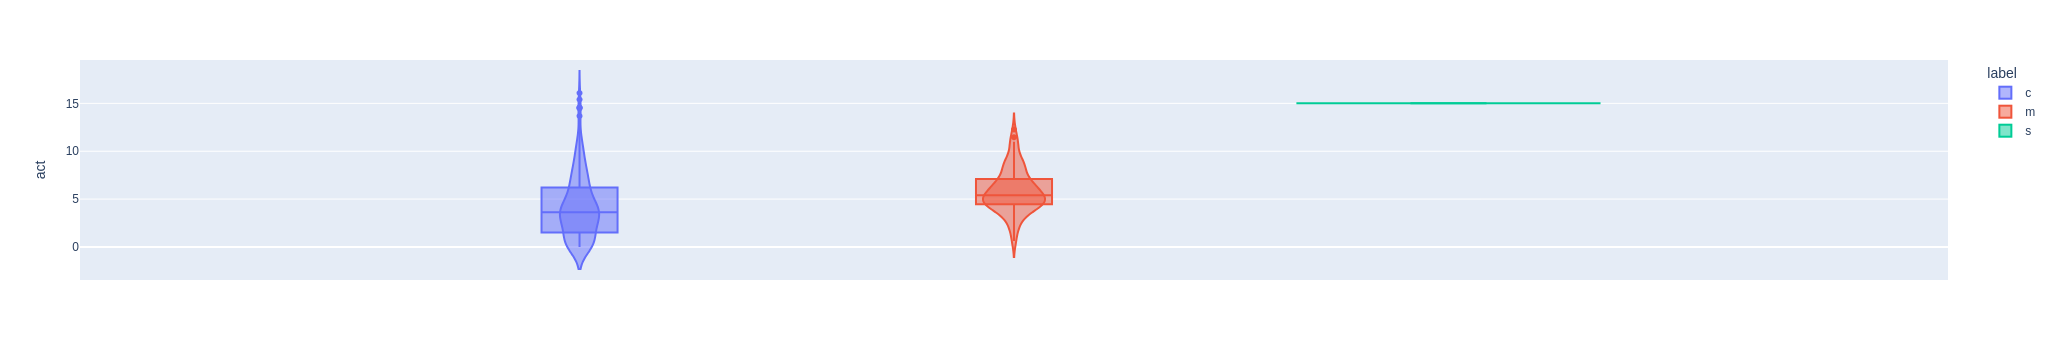

In [12]:
print(asidf.group_by("label").agg([pl.col("act").mean().alias("mean_act"), pl.col("act").count().alias("count")]))
px.violin(asidf, y="act", color="label", box=True)